In [1]:
"""
Optimum Filter v1.3 — hop=1 specialized sliding core + blocked / sparse χ²

Changes vs your v1.2:
- Specialized hop=1 kernel (_slide_block_hop1_*) that updates X and accumulates amp and chi0
  in a single pass over m (better cache locality, fewer temporaries), with fastmath.
- Blocked processing for χ² via `reanchor_every` (each block is re-anchored by a true FFT,
  inner steps use the sliding recurrence). This limits numerical drift and speeds up long traces.
- Optional sparse chi-square: `chisq_mode='none'` to skip χ² in sliding pass, plus
  `chisq_at_indices(...)` helper to compute χ² only at selected windows (e.g., detected peaks).
- Precompute twiddle factors and real/imag of filter kernel, as well as 1/PSD, once per state.

API compatibility:
- `fit`, `fit_with_shift` unchanged.
- `sliding_fit(trace_long, hop=1, reanchor_every=None, chisq_mode='all')` now accepts
  `chisq_mode` in {'all','none'}. When 'none', it returns `chisqs` filled with NaNs.
- New `chisq_at_indices(trace_long, indices)` computes χ² at requested window starts.
"""

import numpy as np
from numba import njit
from numpy.fft import fft, ifft


# -----------------------------
# Numba kernels
# -----------------------------

@njit(cache=True, fastmath=True)
def _eval_amp_chi0(F_re, F_im, invS, X, scale, kern_norm, N):
    amp_acc = 0.0
    chi_acc = 0.0
    for m in range(N):
        xr = X[m].real
        xi = X[m].imag
        amp_acc += F_re[m] * xr - F_im[m] * xi  # Re(F*X)
        chi_acc += (xr * xr + xi * xi) * invS[m]
    amp = amp_acc * scale
    chi0 = chi_acc * scale
    chisq = (chi0 - amp * amp * kern_norm) / (N - 2)
    return amp, chisq


@njit(cache=True, fastmath=True)
def _slide_block_hop1_ampchi(x, fs, F_re, F_im, invS, E_re, E_im, X,
                            start_sample, steps, N, kern_norm, scale,
                            amps, chisqs, out_offset):
    """
    Starting from current window at start_sample (whose FFT is already in X),
    advance `steps` windows by hop=1 using the sliding DFT recurrence.
    For each *new* window, update X, then write amp & chisq to outputs.
    Writes to amps[out_offset : out_offset+steps].
    """
    t = start_sample
    for s in range(steps):
        a = x[t] / fs
        b = x[t + N] / fs
        t += 1

        amp_acc = 0.0
        chi_acc = 0.0
        for m in range(N):
            xr = X[m].real - a + b
            xi = X[m].imag
            # multiply by twiddle E[m] = E_re[m] + 1j*E_im[m]
            xr2 = xr * E_re[m] - xi * E_im[m]
            xi2 = xr * E_im[m] + xi * E_re[m]
            X[m] = xr2 + 1j * xi2

            amp_acc += F_re[m] * xr2 - F_im[m] * xi2
            chi_acc += (xr2 * xr2 + xi2 * xi2) * invS[m]

        amp = amp_acc * scale
        chi0 = chi_acc * scale
        chisq = (chi0 - amp * amp * kern_norm) / (N - 2)
        amps[out_offset + s] = amp
        chisqs[out_offset + s] = chisq


@njit(cache=True, fastmath=True)
def _slide_block_hop1_amponly(x, fs, F_re, E_re, E_im, X,
                             start_sample, steps, N, scale,
                             amps, out_offset):
    """
    Same as _slide_block_hop1_ampchi but accumulates only amplitude (skip χ²).
    Useful for the peak-only χ² workflow.
    """
    t = start_sample
    for s in range(steps):
        a = x[t] / fs
        b = x[t + N] / fs
        t += 1

        amp_acc = 0.0
        for m in range(N):
            xr = X[m].real - a + b
            xi = X[m].imag
            xr2 = xr * E_re[m] - xi * E_im[m]
            xi2 = xr * E_im[m] + xi * E_re[m]
            X[m] = xr2 + 1j * xi2

            amp_acc += F_re[m] * xr2  # since F_im not used, fold into F_re-only path

        amps[out_offset + s] = amp_acc * scale


# Fallback generic kernel for hop>1 (kept close to your original)
@njit(cache=True)
def _compute_amp(F, X, fs, N):
    s = 0.0
    for k in range(N):
        s += F[k].real * X[k].real - F[k].imag * X[k].imag
    return s * fs / N


@njit(cache=True)
def _compute_chi0(X, S_unf, fs, N):
    s = 0.0
    for k in range(N):
        xr = X[k].real
        xi = X[k].imag
        s += (xr * xr + xi * xi) / S_unf[k]
    return s * fs / N


@njit(cache=True)
def _slide_and_eval_generic(x, fs, F, S_unf, E, X, start, hop, steps, N, kernel_norm, amps, chisqs, out_offset):
    t0 = start - hop
    for s in range(steps):
        for u in range(hop):
            t = t0 + u + s * hop
            a = x[t] / fs
            b = x[t + N] / fs
            for m in range(N):
                X[m] = (X[m] - a + b) * E[m]
        amp = _compute_amp(F, X, fs, N)
        chi0 = _compute_chi0(X, S_unf, fs, N)
        chisq = (chi0 - amp * amp * kernel_norm) / (N - 2)
        amps[out_offset + s] = amp
        chisqs[out_offset + s] = chisq


# -----------------------------
# Optimum Filter class
# -----------------------------

class OptimumFilter:
    def __init__(self, template, noise_psd, sampling_frequency):
        self._template = np.asarray(template, dtype=np.float64)
        self._noise_psd = np.asarray(noise_psd, dtype=np.float64)
        self._sampling_frequency = float(sampling_frequency)
        self._update_state()

    def set_template(self, template):
        self._template = np.asarray(template, dtype=np.float64)
        self._update_state()

    def set_noise_psd(self, noise_psd):
        self._noise_psd = np.asarray(noise_psd, dtype=np.float64)
        self._update_state()

    def _update_state(self):
        self._length = int(self._template.size)
        fs = self._sampling_frequency
        N = self._length

        # Unfold PSD to two-sided to match complex FFT convention
        if N % 2 == 0:
            self._noise_psd_unfolded = np.concatenate((
                [np.inf],
                self._noise_psd[1:-1] / 2.0,
                [self._noise_psd[-1]],
                self._noise_psd[-2:0:-1] / 2.0,
            ))
        else:
            self._noise_psd_unfolded = np.concatenate((
                [np.inf],
                self._noise_psd[1:] / 2.0,
                self._noise_psd[-1:0:-1] / 2.0,
            ))

        self._template_fft = fft(self._template) / fs

        self._kernel_fft = self._template_fft.conjugate() / self._noise_psd_unfolded
        self._kernel_normalization = (
            np.real(np.dot(self._kernel_fft, self._template_fft)) * fs / N
        )
        self._filter_kernel = self._kernel_fft / self._kernel_normalization

        # Precomputes for the new kernels
        self._F_real = np.ascontiguousarray(self._filter_kernel.real.astype(np.float64))
        self._F_imag = np.ascontiguousarray(self._filter_kernel.imag.astype(np.float64))
        self._inv_noise_psd_unf = np.ascontiguousarray((1.0 / self._noise_psd_unfolded).astype(np.float64))

        m = np.arange(N, dtype=np.float64)
        E = np.exp(2j * np.pi * m / N).astype(np.complex128)
        self._E = np.ascontiguousarray(E)
        self._E_real = np.ascontiguousarray(E.real.astype(np.float64))
        self._E_imag = np.ascontiguousarray(E.imag.astype(np.float64))

    # ----------------- single-window fits -----------------

    def fit(self, trace):
        trace_fft = fft(trace, axis=-1) / self._sampling_frequency  # V
        trace_filtered = self._filter_kernel * trace_fft
        amp = np.real(trace_filtered.sum(axis=-1)) * self._sampling_frequency / self._length
        chisq0 = np.real((trace_fft.conj() * trace_fft / self._noise_psd_unfolded).sum()) * self._sampling_frequency / self._length
        chisq = (chisq0 - amp ** 2 * self._kernel_normalization) / (self._length - 2)
        return float(amp), float(chisq)

    def fit_with_shift(self, trace, allowed_shift_range=None):
        trace_fft = fft(trace, axis=-1) / self._sampling_frequency  # V
        trace_filtered = self._filter_kernel * trace_fft
        trace_filtered_td = np.real(ifft(trace_filtered, axis=-1)) * self._sampling_frequency

        chi0 = np.real((trace_fft.conj() * trace_fft / self._noise_psd_unfolded).sum()) * self._sampling_frequency / self._length
        chit_withdelay = (trace_filtered_td ** 2) * self._kernel_normalization
        chi = chi0 - chit_withdelay

        if allowed_shift_range is None:
            ind = np.arange(len(chi))
        else:
            ind = np.concatenate((
                np.arange(self._length + allowed_shift_range[0], self._length),
                np.arange(allowed_shift_range[1] + 1),
            ))

        best_ind = ind[np.argmin(chi[ind], axis=-1)]

        amp = trace_filtered_td[best_ind]
        chisq = chi[best_ind] / (self._length - 3)
        t0 = int(best_ind if best_ind < self._length // 2 else best_ind - self._length)
        return float(amp), float(chisq), int(t0)

    # ----------------- sliding fits -----------------

    def sliding_fit(self, trace_long, hop=1, reanchor_every=None, chisq_mode='all'):
        """
        Sliding OF fit along a long trace.

        Parameters
        ----------
        trace_long : array_like
            Long 1D trace.
        hop : int, default 1
            Step in samples between consecutive windows. The specialized fast path
            is activated for hop==1.
        reanchor_every : int or None
            Number of windows per block before re-anchoring by FFT. If None,
            a single block is used (i.e., re-anchor only at the very beginning).
        chisq_mode : {'all','none'}
            'all': compute χ² per window (blocked within each re-anchored block).
            'none': skip χ² in the sliding pass and return NaNs. Use
                    `chisq_at_indices(...)` later for sparse χ².

        Returns
        -------
        amps : (num_windows,) float64
        chisqs : (num_windows,) float64  (NaNs when chisq_mode='none')
        """
        x = np.asarray(trace_long, dtype=np.float64)
        L = x.size
        N = self._length
        fs = self._sampling_frequency

        if N <= 0 or L < N:
            raise ValueError("Trace shorter than window length or invalid N.")
        if hop <= 0:
            raise ValueError("hop must be a positive integer.")

        num_windows = 1 + (L - N) // hop
        amps = np.empty(num_windows, dtype=np.float64)
        chisqs = np.empty(num_windows, dtype=np.float64)
        scale = fs / N
        kern_norm = float(self._kernel_normalization)

        if hop == 1:
            # Blocked processing with hop=1 specialized kernels
            block = int(reanchor_every) if reanchor_every else num_windows
            out_idx = 0
            start_win = 0

            while start_win < num_windows:
                steps_in_block = min(block, num_windows - start_win)
                start_sample = start_win  # since hop==1, window start == index

                # Initial FFT at this block's start
                X = fft(x[start_sample : start_sample + N]) / fs
                X = np.ascontiguousarray(X.astype(np.complex128))

                if chisq_mode == 'all':
                    # Evaluate first window (no slide yet)
                    amp0, chisq0 = _eval_amp_chi0(
                        self._F_real, self._F_imag, self._inv_noise_psd_unf, X,
                        scale, kern_norm, N
                    )
                    amps[out_idx] = amp0
                    chisqs[out_idx] = chisq0

                    if steps_in_block > 1:
                        _slide_block_hop1_ampchi(
                            x, fs, self._F_real, self._F_imag, self._inv_noise_psd_unf,
                            self._E_real, self._E_imag, X,
                            start_sample, steps_in_block - 1, N, kern_norm, scale,
                            amps, chisqs, out_idx + 1,
                        )
                elif chisq_mode == 'none':
                    # First window amplitude only
                    amp0, _ = _eval_amp_chi0(
                        self._F_real, self._F_imag, self._inv_noise_psd_unf, X,
                        scale, kern_norm, N
                    )
                    amps[out_idx] = amp0
                    chisqs[out_idx] = np.nan

                    if steps_in_block > 1:
                        _slide_block_hop1_amponly(
                            x, fs, self._F_real, self._E_real, self._E_imag, X,
                            start_sample, steps_in_block - 1, N, scale,
                            amps, out_idx + 1,
                        )
                        chisqs[out_idx + 1 : out_idx + steps_in_block] = np.nan
                else:
                    raise ValueError("chisq_mode must be 'all' or 'none'.")

                out_idx += steps_in_block
                start_win += steps_in_block

            return amps, chisqs

        # -------- fallback generic path for hop>1 --------
        # Twiddle (complex) for generic recurrence
        E = self._E  # complex128
        F = np.ascontiguousarray(self._filter_kernel.astype(np.complex128))
        S_unf = np.ascontiguousarray(self._noise_psd_unfolded.astype(np.float64))

        X = fft(x[0:N]) / fs
        X = np.ascontiguousarray(X.astype(np.complex128))

        # First window outputs
        amp0 = _compute_amp(F, X, fs, N)
        chi00 = _compute_chi0(X, S_unf, fs, N)
        chisq0 = (chi00 - amp0 * amp0 * kern_norm) / (N - 2)
        amps[0] = amp0
        chisqs[0] = chisq0

        made = 1
        start = hop

        while start <= L - N:
            if reanchor_every and (made % reanchor_every == 0):
                X[:] = fft(x[start:start + N]) / fs
                amp = _compute_amp(F, X, fs, N)
                chi0 = _compute_chi0(X, S_unf, fs, N)
                chisq = (chi0 - amp * amp * kern_norm) / (N - 2)
                amps[made] = amp
                chisqs[made] = chisq
                made += 1
                start += hop
            else:
                if reanchor_every:
                    steps_to_reanchor = reanchor_every - (made % reanchor_every)
                else:
                    steps_to_reanchor = (L - N - start) // hop + 1
                steps_to_end = (L - N - start) // hop + 1
                steps = min(steps_to_reanchor, steps_to_end)
                if steps <= 0:
                    break

                _slide_and_eval_generic(
                    x, fs, F, S_unf, E, X,
                    start, hop, steps, N, kern_norm,
                    amps, chisqs, made,
                )
                made += steps
                start += steps * hop

        return amps, chisqs

    # ----------------- sparse χ² helper -----------------

    def chisq_at_indices(self, trace_long, indices):
        """
        Compute χ² *only* at selected window start indices.

        Parameters
        ----------
        trace_long : array_like
        indices : array_like of ints (window start sample indices)

        Returns
        -------
        chisqs : (len(indices),) float64
        amps   : (len(indices),) float64  (amplitude recomputed at those windows)
        """
        x = np.asarray(trace_long, dtype=np.float64)
        idx = np.asarray(indices, dtype=np.int64)
        N = self._length
        fs = self._sampling_frequency
        kern_norm = float(self._kernel_normalization)

        chis = np.empty(idx.size, dtype=np.float64)
        amps = np.empty(idx.size, dtype=np.float64)

        for j, s in enumerate(idx):
            if s < 0 or s + N > x.size:
                chis[j] = np.nan
                amps[j] = np.nan
                continue
            X = fft(x[s : s + N]) / fs
            amp = (self._F_real @ X.real - self._F_imag @ X.imag) * fs / N
            chi0 = ((X.real * X.real + X.imag * X.imag) * self._inv_noise_psd_unf).sum() * fs / N
            chis[j] = (chi0 - amp * amp * kern_norm) / (N - 2)
            amps[j] = amp

        return chis, amps


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from OptimumFilter import *

sampling_frequency = 3906250
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of = OptimumFilter(vac_template, noise_psd, sampling_frequency)


data = np.load("separate_trace.npz")
signal = data["signal"]
noise = data["noise"]
quantized = data["quantized"] 
unquantized = data["unquantized"] 

In [4]:
amps_signal_0, chisq_signal_0 = vac_of.sliding_fit(signal, hop=1)


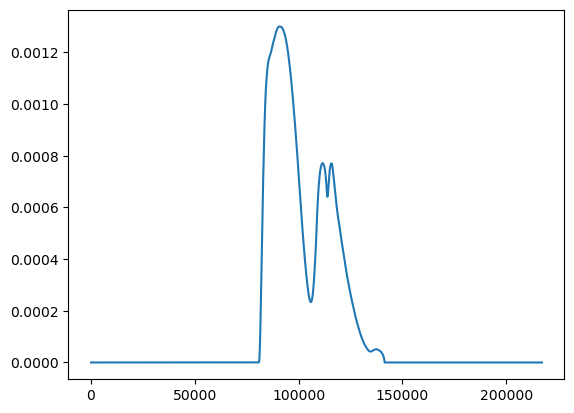

In [3]:
plt.plot(chisq_signal_0)
plt.show()

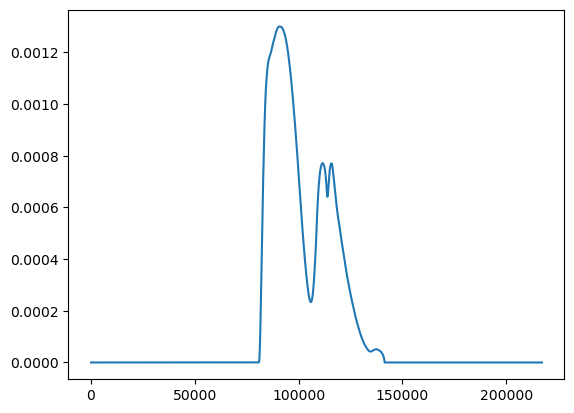

In [10]:
plt.plot(chisq_signal_0)
plt.show()

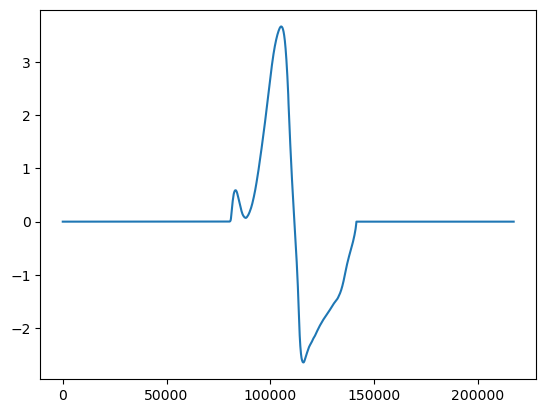

In [9]:
plt.plot(amps_signal_0)
plt.show()

In [10]:
sampling_frequency = 3906250
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of_2 = OptimumFilter(vac_template, noise_psd, sampling_frequency)

In [12]:
amps_signal, chisq_signal, _= vac_of_2.sliding_fit(signal, hop=1)


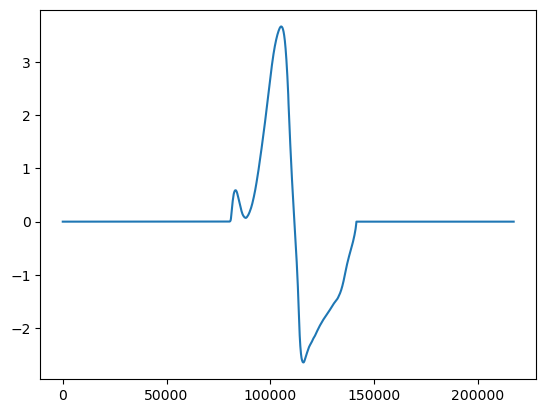

In [13]:
plt.plot(amps_signal)